In [1]:
import torch

In [2]:
device = torch.device('cuda')
device

device(type='cuda')

In [4]:
!nvidia-smi

Mon May 11 23:48:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.14                 Driver Version: 566.14         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   60C    P8              1W /   45W |     233MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
a = torch.linspace(0.0001, 0.02, steps=200)
a
alpha = 1.0 - a
alpha

tensor([0.9999, 0.9998, 0.9997, 0.9996, 0.9995, 0.9994, 0.9993, 0.9992, 0.9991,
        0.9990, 0.9989, 0.9988, 0.9987, 0.9986, 0.9985, 0.9984, 0.9983, 0.9982,
        0.9981, 0.9980, 0.9979, 0.9978, 0.9977, 0.9976, 0.9975, 0.9974, 0.9973,
        0.9972, 0.9971, 0.9970, 0.9969, 0.9968, 0.9967, 0.9966, 0.9965, 0.9964,
        0.9963, 0.9962, 0.9961, 0.9960, 0.9959, 0.9958, 0.9957, 0.9956, 0.9955,
        0.9954, 0.9953, 0.9952, 0.9951, 0.9950, 0.9949, 0.9948, 0.9947, 0.9946,
        0.9945, 0.9944, 0.9943, 0.9942, 0.9941, 0.9940, 0.9939, 0.9938, 0.9937,
        0.9936, 0.9935, 0.9934, 0.9933, 0.9932, 0.9931, 0.9930, 0.9929, 0.9928,
        0.9927, 0.9926, 0.9925, 0.9924, 0.9923, 0.9922, 0.9921, 0.9920, 0.9919,
        0.9918, 0.9917, 0.9916, 0.9915, 0.9914, 0.9913, 0.9912, 0.9911, 0.9910,
        0.9909, 0.9908, 0.9907, 0.9906, 0.9905, 0.9904, 0.9903, 0.9902, 0.9901,
        0.9900, 0.9899, 0.9898, 0.9897, 0.9896, 0.9895, 0.9894, 0.9893, 0.9892,
        0.9891, 0.9890, 0.9889, 0.9888, 

In [13]:
alpha_bar  = torch.cumprod(alpha, dim=0)
alpha_bar

tensor([0.9999, 0.9997, 0.9994, 0.9990, 0.9985, 0.9979, 0.9972, 0.9964, 0.9955,
        0.9945, 0.9934, 0.9922, 0.9909, 0.9895, 0.9881, 0.9865, 0.9848, 0.9830,
        0.9812, 0.9792, 0.9771, 0.9750, 0.9728, 0.9704, 0.9680, 0.9655, 0.9629,
        0.9602, 0.9574, 0.9545, 0.9516, 0.9485, 0.9454, 0.9422, 0.9389, 0.9355,
        0.9320, 0.9285, 0.9249, 0.9212, 0.9174, 0.9135, 0.9096, 0.9056, 0.9015,
        0.8974, 0.8932, 0.8889, 0.8845, 0.8801, 0.8756, 0.8711, 0.8664, 0.8618,
        0.8570, 0.8522, 0.8474, 0.8425, 0.8375, 0.8325, 0.8274, 0.8223, 0.8171,
        0.8118, 0.8066, 0.8012, 0.7959, 0.7905, 0.7850, 0.7795, 0.7740, 0.7684,
        0.7628, 0.7572, 0.7515, 0.7458, 0.7400, 0.7342, 0.7284, 0.7226, 0.7168,
        0.7109, 0.7050, 0.6991, 0.6931, 0.6872, 0.6812, 0.6752, 0.6692, 0.6632,
        0.6571, 0.6511, 0.6450, 0.6390, 0.6329, 0.6268, 0.6207, 0.6147, 0.6086,
        0.6025, 0.5964, 0.5903, 0.5842, 0.5782, 0.5721, 0.5660, 0.5600, 0.5539,
        0.5479, 0.5419, 0.5358, 0.5298, 

In [2]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import requests
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP THE MATH (The Schedule)
# ==========================================
T = 200 # Total timesteps
beta = torch.linspace(0.0001, 0.02, T) # Linear noise schedule
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

# Pre-calculate square roots for the forward equation
sqrt_alpha_bar = torch.sqrt(alpha_bar)
sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)



In [3]:
# ==========================================
# 2. THE FORWARD EQUATION (Equation 25.3)
# ==========================================
def forward_diffusion(x_0, t):
    """Adds noise to the original image x_0 up to timestep t."""
    noise = torch.randn_like(x_0)
    
    # Reshape constants so they broadcast correctly over the image tensor [Batch, Channels, Height, Width]
    sqrt_a_bar_t = sqrt_alpha_bar[t].view(-1, 1, 1, 1)
    sqrt_one_minus_a_bar_t = sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
    
    # The Master Forward Equation
    x_t = (sqrt_a_bar_t * x_0) + (sqrt_one_minus_a_bar_t * noise)
    return x_t



In [22]:
img = torch.randn(1, 3, 256, 256) # Simulate a batch of 1 image with 3 channels (RGB) and size 256x256
img.shape

torch.Size([1, 3, 256, 256])

In [23]:
noise = torch.randn_like(img)
noise.shape

torch.Size([1, 3, 256, 256])

In [25]:
img

tensor([[[[ 5.7318e-01,  1.6483e+00,  1.0827e+00,  ..., -1.1707e+00,
           -2.2596e+00, -1.0527e+00],
          [ 1.4751e+00, -7.3561e-01,  1.8495e-01,  ..., -1.4096e+00,
           -3.6239e-01, -1.9695e+00],
          [-7.3090e-01, -2.0807e-01, -1.5846e-01,  ..., -1.0960e+00,
            3.7639e-01, -2.3519e-01],
          ...,
          [-2.8170e+00, -2.9647e-01, -1.7272e-01,  ...,  5.0270e-01,
            1.9987e+00, -1.6226e+00],
          [-1.2651e+00, -6.6166e-01, -5.4912e-02,  ...,  1.0338e+00,
           -6.4605e-01,  8.2322e-01],
          [ 4.3616e-01,  7.5215e-01, -1.6712e+00,  ..., -1.0767e-01,
           -8.6954e-01, -5.3459e-01]],

         [[-6.7849e-02,  1.3698e+00, -1.7005e-01,  ..., -1.6875e+00,
           -1.6265e+00, -6.4942e-01],
          [ 8.0118e-01, -1.1618e+00,  5.2504e-01,  ...,  7.9073e-01,
            4.6796e-01,  8.0915e-02],
          [-8.4034e-01,  6.9276e-02, -1.1974e+00,  ..., -4.5430e-01,
            6.4116e-01, -1.4473e+00],
          ...,
     

In [24]:
noise

tensor([[[[-3.1257, -0.8679,  0.8509,  ..., -0.1227,  0.3402,  1.7279],
          [-0.5688,  0.9306,  1.9914,  ..., -3.2707, -0.1940,  0.1890],
          [ 0.1443,  2.6614, -1.3102,  ...,  0.9767,  0.8619, -0.6214],
          ...,
          [ 0.2275,  0.7778,  0.3965,  ...,  0.6004, -0.9310,  0.7018],
          [ 0.3953,  0.1813, -0.3974,  ...,  0.5374,  0.3053, -1.3212],
          [ 1.2311,  0.6528,  0.0886,  ..., -0.1518,  0.3962, -0.7471]],

         [[ 0.4672,  0.1988,  0.3991,  ...,  0.8599, -0.0302, -2.0927],
          [ 0.2833,  0.8216,  0.5246,  ...,  0.8754,  0.9412, -0.1921],
          [ 1.2845,  1.5350,  1.2952,  ..., -1.4040, -0.6234,  0.7445],
          ...,
          [-1.5880, -0.5233, -0.2973,  ..., -0.4690,  0.1361, -0.3146],
          [ 1.5350, -0.2705,  0.6038,  ..., -0.8869,  0.5912, -0.5041],
          [-0.5416, -2.2657,  0.6628,  ..., -1.6797, -1.0261,  0.7053]],

         [[ 1.6582,  0.0629,  0.5641,  ...,  0.1598,  1.2375, -0.0809],
          [-0.3492,  1.0595,  

In [15]:
url = "https://images.unsplash.com/photo-1543466835-00a7907e9de1?q=80&w=400&auto=format&fit=crop"
image = Image.open(requests.get(url, stream=True).raw)

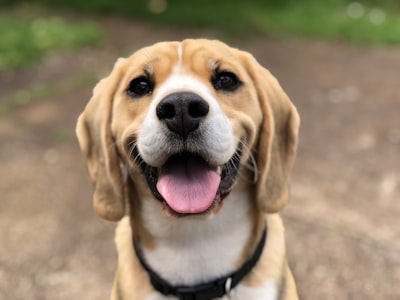

In [16]:
image

In [17]:
transform = transforms.Compose([
    transforms.Resize((256, 256)), # Standardize size
    transforms.ToTensor(),         # Converts to [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Scales to [-1, 1]
])
x_0 = transform(image).unsqueeze(0) # Add batch dimension

In [18]:
x_0.shape

torch.Size([1, 3, 256, 256])

In [4]:
# ==========================================
# 3. GET A REAL IMAGE
# ==========================================
# Download a cute dog image from a public URL
url = "https://images.unsplash.com/photo-1543466835-00a7907e9de1?q=80&w=400&auto=format&fit=crop"
image = Image.open(requests.get(url, stream=True).raw)

# PyTorch models expect images as Tensors scaled between [-1, 1]
transform = transforms.Compose([
    transforms.Resize((256, 256)), # Standardize size
    transforms.ToTensor(),         # Converts to [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Scales to [-1, 1]
])

# Apply transforms and add a Batch dimension so shape is [1, 3, 256, 256]
x_0 = transform(image).unsqueeze(0) 



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


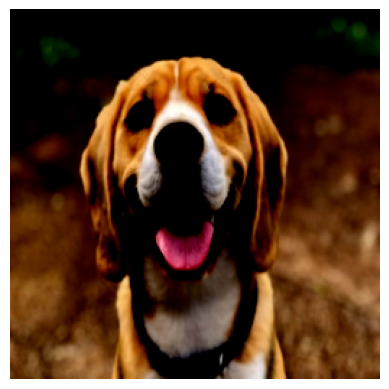

In [19]:
img = x_0.squeeze(0).permute(1,2,0).numpy()
plt.imshow(img)
plt.axis("off")
plt.show() 

In [38]:
T = torch.arange(0,210,10)
T

tensor([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
        140, 150, 160, 170, 180, 190, 200])

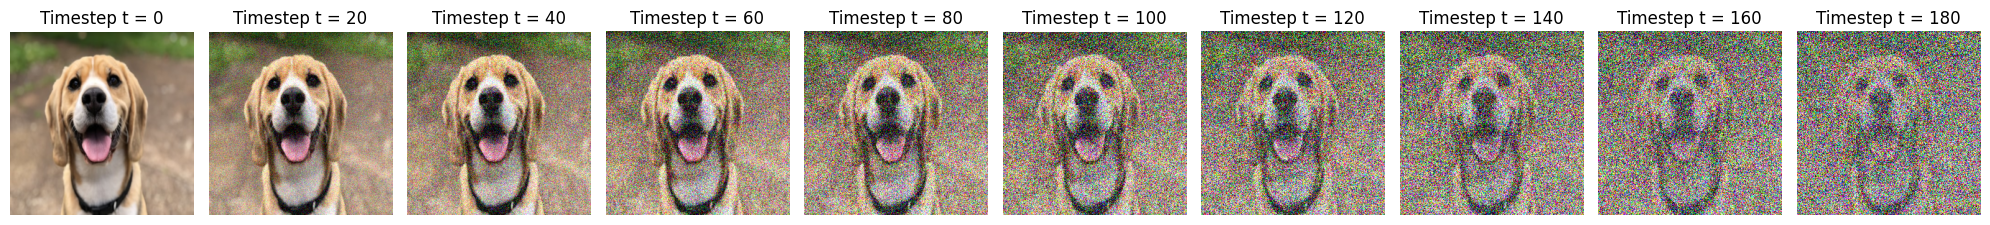

In [6]:
# ==========================================
# 4. EXPERIMENT & VISUALIZE
# ==========================================
# We want to see the image at t=0, t=40, t=80, t=120, t=199
timesteps = torch.arange(0, T, 20) # [0, 40, 80, 120, 199]

fig, axes = plt.subplots(1, len(timesteps), figsize=(20, 3))

def tensor_to_image(tensor):
    """Helper function to convert a PyTorch tensor back to a viewable image."""
    tensor = tensor.squeeze(0).permute(1, 2, 0) # Remove batch, change shape to [H, W, C]
    tensor = (tensor + 1.0) / 2.0 # Reverse the [-1, 1] normalization back to [0, 1]
    return torch.clamp(tensor, 0, 1).numpy()

for i, t in enumerate(timesteps):
    if t == 0:
        # At t=0, it's just the original image
        noisy_image = x_0
    else:
        # Convert t to a tensor so our function can process it
        t_tensor = torch.tensor([t])
        # Apply the fast-forward math!
        noisy_image = forward_diffusion(x_0, t_tensor)
        
    ax = axes[i]
    ax.imshow(tensor_to_image(noisy_image))
    ax.set_title(f"Timestep t = {t}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
import sys
!{sys.executable} -m pip install gradio

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\MSI-1\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
